# PNPedia interface

This notebook demonstrates how to use `PyART.analytic.pnpedia.PNPedia` to load a PN quantity from a local PNPedia repository checkout and plot it as a function of the PN parameter `x`.

Quantity: `energy_circular_nonspinning_binding` (nonspinning, circular, non-tidal, binding energy).

`get_pn_quantity()` returns an `AnalyticExpression`. Calling `.to_function()` on that object returns a callable together with the symbolic argument order it expects.

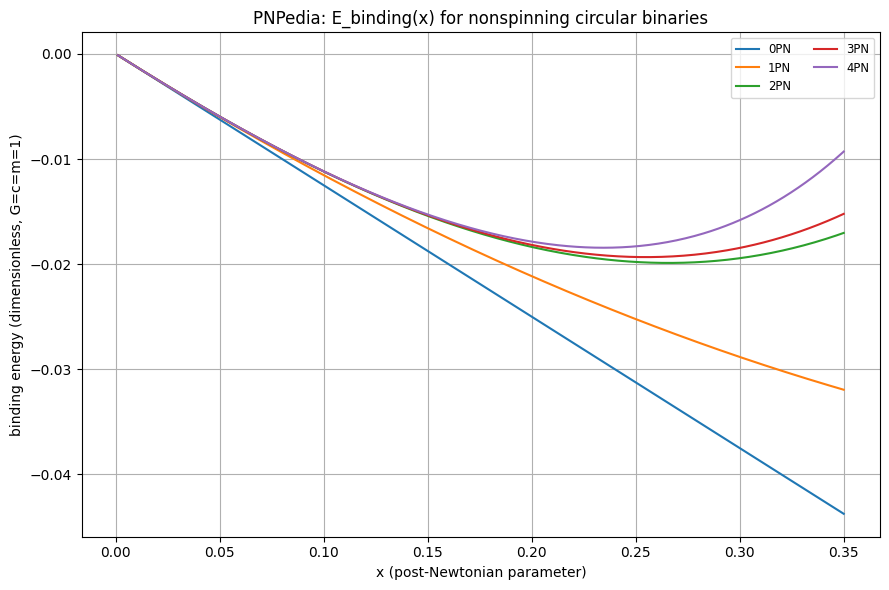

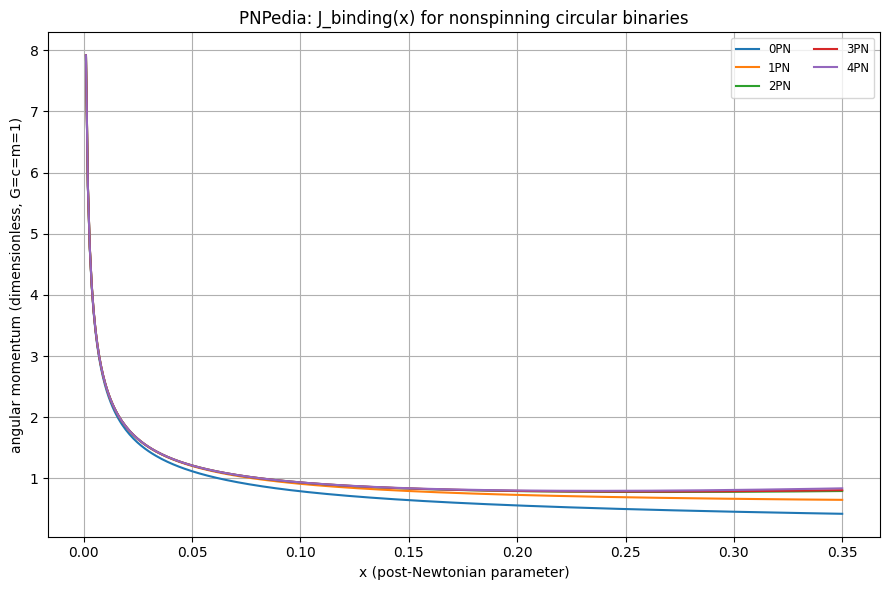

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "PyART").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the PyART repository root from the notebook working directory."
    )


repo_root = find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from PyART.analytic.pnpedia import PNPedia

# Clone or reuse a local PNPedia checkout under the repository root.
pnpedia_path = repo_root / "PNPedia"
npd = PNPedia(path=str(pnpedia_path), download=not pnpedia_path.exists())

# PN variable x range for circular inspiral (small x region)
x = np.linspace(0.001, 0.35, 400)

# Evaluate with geometric-like normalized constants and symmetric mass ratio nu=0.25.
# Set G=c=m=b0=1 for demonstration, then tune as required for a specific use case.
value_map = {"G": 1.0, "b0": 1.0, "c": 1.0, "m": 1.0, "nu": 0.25, "x": x}

energy_orders = [0, 1, 2, 3, 4]
angular_momentum_orders = [0, 1, 2, 3, 4]


def evaluate_expression(expression):
    analytic_func, variables = expression.to_function()
    args = [value_map[str(symbol)] for symbol in variables]
    return analytic_func(*args), variables


# 1) Plot E(x) for multiple PN truncations
plt.figure(figsize=(9, 6))
for order in energy_orders:
    energy_expr = npd.get_pn_quantity(
        "energy_circular_nonspinning_binding", order=order
    )
    energy, _ = evaluate_expression(energy_expr)
    plt.plot(x, energy, lw=1.5, label=f"{order}PN")

plt.xlabel("x (post-Newtonian parameter)")
plt.ylabel("binding energy (dimensionless, G=c=m=1)")
plt.title("PNPedia: E_binding(x) for nonspinning circular binaries")
plt.grid(True)
plt.legend(ncol=2, fontsize="small")
plt.tight_layout()
plt.show()

# 2) Plot J(x) for multiple PN truncations
plt.figure(figsize=(9, 6))
for order in angular_momentum_orders:
    angular_momentum_expr = npd.get_pn_quantity(
        "angular_momentum_circular_nonspinning_conservative", order=order
    )
    angmom, _ = evaluate_expression(angular_momentum_expr)
    plt.plot(x, angmom, lw=1.5, label=f"{order}PN")

plt.xlabel("x (post-Newtonian parameter)")
plt.ylabel("angular momentum (dimensionless, G=c=m=1)")
plt.title("PNPedia: J_binding(x) for nonspinning circular binaries")
plt.grid(True)
plt.legend(ncol=2, fontsize="small")
plt.tight_layout()
plt.show()

## Compare the analytical PN binding energy to a NR curve

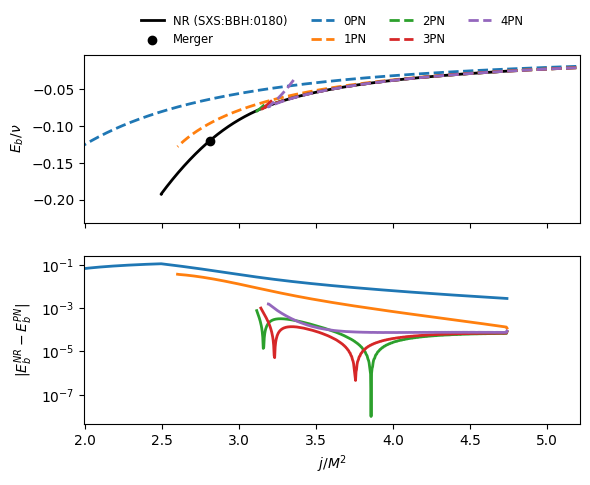

In [ ]:
# binding energy vs angular momentum plot, compare with NR
# Note: this NR comparison is rather "naive". One should in principle shift the NR curve
# such that the final state (remnant) coincides with the last point of the NR curve, see
# the appendix of https://arxiv.org/pdf/1506.08457

from PyART.catalogs import sxs

# NR curve from the SXS catalog
sxs_waveform = sxs.Waveform_SXS(
    ID="0180",
    download=True,
    ignore_deprecation=True,
    downloads=["hlm", "metadata", "horizons"],
    load=["hlm", "metadata", "horizons"],
)
t_max, _, _, _, mrg_idx = sxs_waveform.find_max(return_idx=True, mode=(2, 2))
M_adm_0 = sxs_waveform.metadata["E0byM"]
J_adm_0 = sxs_waveform.metadata["Jz0"]
m1 = sxs_waveform.metadata["m1"]
m2 = sxs_waveform.metadata["m2"]
modes = [(2, 2), (2, 1), (3, 3), (4, 4), (2, -2), (2, -1), (3, -3), (4, -4)]
eb, e, jorb = sxs_waveform.ej_from_hlm(M_adm_0, J_adm_0, m1, m2, modes=modes)

# identify NR merger
e_mrg = eb[mrg_idx]
j_mrg = jorb[mrg_idx]

fig, ax = plt.subplots(2, 1, sharex=True)
ax0, ax1 = ax
ax0.plot(jorb, eb, "k-", lw=2, label="NR (SXS:BBH:0180)")
ax0.scatter(j_mrg, e_mrg, color="k", label="Merger")

# Flip arrays to have increasing J/nu for interpolation.
jorb = jorb[::-1]
eb = eb[::-1]

# PN curve (NPN order)
for order, color in zip(energy_orders, ["C0", "C1", "C2", "C3", "C4"]):
    energy_expr = npd.get_pn_quantity(
        "energy_circular_nonspinning_binding", order=order
    )
    angular_momentum_expr = npd.get_pn_quantity(
        "angular_momentum_circular_nonspinning_conservative", order=order
    )

    E, _ = evaluate_expression(energy_expr)
    J, _ = evaluate_expression(angular_momentum_expr)

    ax0.plot(
        J / value_map["nu"],
        E / value_map["nu"],
        "--",
        color=color,
        lw=2,
        label=f"{order}PN",
    )

    # Plot residuals after interpolating both curves on a shared J grid.
    jmin, jmax = np.min(J / value_map["nu"]), np.max(jorb)
    jint = np.linspace(jmin, jmax, 500)
    idx_min = np.argmin(np.abs(J / value_map["nu"] - jmin))
    J_plot = J[: idx_min - 1][::-1]
    E_plot = E[: idx_min - 1][::-1]

    eb_nr_int = np.interp(jint, jorb, eb)
    eb_pn_int = np.interp(jint, J_plot / value_map["nu"], E_plot / value_map["nu"])
    deltaE = np.abs(eb_nr_int - eb_pn_int)
    ax1.semilogy(jint, deltaE, "-", lw=2, color=color, label=f"{order}PN")

ax0.set_xlim(np.min(jorb) * 0.8, np.max(jorb) * 1.1)
ax0.set_ylim(np.min(eb) * 1.2, np.max(eb) * 0.1)
ax0.set_ylabel(r"$E_b/\nu$")
# legend out of plot, on top and horizontal
ax0.legend(loc="upper center",
           bbox_to_anchor=(0.5, 1.3),
           ncol=4, fontsize="small",
           fancybox=False,
           edgecolor='none'
        )
ax1.set_xlabel(r"$j/M^2$")
ax1.set_ylabel(r"$|E_b^{NR} - E_b^{PN}|$")
plt.show()

## Inspect the analytical expression, manipulate it, and evaluate it

The `AnalyticExpression` class wraps SymPy expressions and provides a small interface for differentiation, truncation, and numerical evaluation.

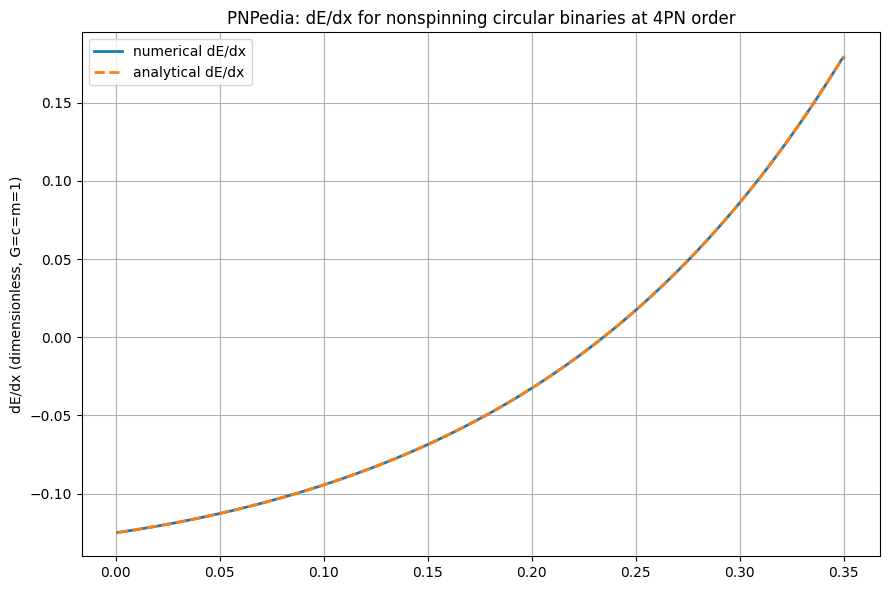

In [3]:
analytic_E = npd.get_pn_quantity("energy_circular_nonspinning_binding", order=4)
analytic_E_dvt = analytic_E.derivative("x")

analytic_E_values, _ = evaluate_expression(analytic_E)
analytic_E_dvt_values, _ = evaluate_expression(analytic_E_dvt)

# Plot the numerical derivative and the analytical one.
numerical_dvt = np.gradient(analytic_E_values, x)
plt.figure(figsize=(9, 6))
plt.plot(x, numerical_dvt, label="numerical dE/dx", lw=2)
plt.plot(x, analytic_E_dvt_values, label="analytical dE/dx", lw=2, ls="--")
plt.ylabel("dE/dx (dimensionless, G=c=m=1)")
plt.title("PNPedia: dE/dx for nonspinning circular binaries at 4PN order")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# AnalyticExpression objects can be added, subtracted, multiplied, divided, etc.
# to create new derived quantities, exactly like standard SymPy expressions.
# further, they also inherit methods like .to_latex() for easy conversion

from PyART.analytic import AnalyticExpression

simple_expression_1 = AnalyticExpression("x**2 + 3*x + 5 + 5*q", var=["x", "q"])
simple_expression_2 = AnalyticExpression("2*x**3 - x + 1", var=["x"])

derived_expression = simple_expression_1 + simple_expression_2

print(derived_expression.expr)
print(derived_expression.truncate("x", 2).expr)  # truncate to x^2 order
print(derived_expression.to_latex())  # convert to LaTeX string

5*q + 2*x**3 + x**2 + 2*x + 6
5*q + x**2 + 2*x + 6
5 q + 2 x^{3} + x^{2} + 2 x + 6
